# Maximum Likelihood Estimation

In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.stats import norm
from math import sqrt, pi, exp

import os

### Maximum Likelihood Estimator (MLE)
* Observed data is given
* Choose a Probability Model
* Find the values of mu and sigma which would make observed data most probable

### MLE Explained in Details
* Given the outcome, estimate the parameters which resulted in the outcome
* For set of data points `{x1, x2, x3, ... , xn}`, and a model with parameters `theta`, the Likelihood of `theta` is
```
    L(theta) = P(x1, x2, x3 ... , xn | theta)
```
* Fitting data to a Normal Distribution with model parameters `(mu, sigma)` represented by `theta = { mu, sigma }`

The probability density function of normal or Gaussian distribution is given as <br> 

 $$
  N(\mu,\sigma)=\frac{1}{\sqrt(2\pi)\sigma} \exp^{\frac{-(x-\mu)^2}{2\sigma^2}}
 $$
 Let's call this function $f(x)$ <br>
The parameter set which is represented with $\theta$ In case of normal distribution it is given as $\theta=\{\mu,\sigma\}$  <br>
Now the likelihood for a dataset (which says the data is likely to have some parameters) is reresented as <br>

$$
L(\theta/data) = L(\mu,\sigma/data)
$$
The likelihod is obtained by multiplying all the densities, therefore, <br>
$$
L(\mu,\sigma/data)= f(x_1)*f(x_2)*.....f(x_n) \\
L(\mu,\sigma/data)=\prod_{i=1}^N f(x_i)
$$
Here $f(x_i)$ is normal distribution function <br>
The density values are usually very small numbers as they are probabilities for large data points and multiplying all the values will result in underflow. So we take logarithm on both sides to avoid this.Therefore<br>
$$
\log(L(\mu,\sigma/data))=\log(\prod_{i=1}^N f(x_i))\\
\log(L(\mu,\sigma/data))=\sum_{i=1}^{N} log (f(x_i))
$$
(Because $log(a*b)=log(a)+log(b)$)

Therefore ``` loglike = np.sum(np.log(Norm))  # Log-likelihood ``` is used here

### Read the CSV data

In [198]:
homedir=os.environ['HOME'] + '/'
datapath=homedir + 'datasets/'
predmaint="predictive_maintenance.csv"

### Create pandas dataframe

In [199]:
pmfile=f"{datapath}{predmaint}"
pm_data = pd.read_csv(pmfile)
# To obtain the feature name for use in datafrae groupby operation
#print(pm_data.head())

## Feature Names

In [200]:
feature_names = [
    'Air temperature [K]', 
    'Process temperature [K]', 
    'Rotational speed [rpm]', 
]

* Compute mean, standard deviation for one feature

In [201]:
air_temp = pm_data['Air temperature [K]'].values
air_temp_mu = np.mean(air_temp)
air_temp_sigma = np.std(air_temp)
print(f"air_temp mean = {air_temp_mu}")
print(f"air_temp sigma = {air_temp_sigma}")

air_temp mean = 300.00493
air_temp sigma = 2.0001586674811573


* Compute Normal or Gaussian Distribution based on above formulae

In [202]:
tmp = ((air_temp - air_temp_mu) ** 2) / (2 * air_temp_sigma ** 2)  # Numerator (exponent part)
npdf_num = np.exp(-tmp)  # Exponentiation
npdf_den = 1 / (np.sqrt(2 * np.pi) * air_temp_sigma)  # Denominator (normalizing constant)
norm = npdf_num * npdf_den  # PDF values (Densities)
print(norm[norm == 0])  # Check for zero values in the PDF
norm[norm == 0] = 1e-300  # Replace zero values with a very small number
print(f"PDF values for Air Temperature: {norm[:5]}")

[]
PDF values for Air Temperature: [0.12673109 0.13274544 0.12673109 0.13274544 0.13274544]


In [203]:
# Feature colors
feature_colors = {
    'Air temperature [K]': 'blue',
    'Process temperature [K]': 'orange',
    'Rotational speed [rpm]': 'green'
}

## FeatureStats class 
* Generic class which represents a feature
* Properties - mu, sigmal, raw data, distribution (Normal PDF)

In [204]:
@dataclass
class FeatureStats:
    mu: float
    sigma: float
    feature_name: str
    x: np.ndarray  # raw data needed for initialization
    distribution: np.ndarray = None
    xspace: np.ndarray = None
    color: str = None # Default color for plotting

    def __post_init__(self):
          # print(f"Post Initializing FeatureStats for {self.feature_name} with mu={self.mu}, sigma={self.sigma}")
          self.compute_xspace(self.x)
          self.compute_pdf(self.xspace)

    def compute_pdf(self, x):
        self.distribution = (1 / (self.sigma * np.sqrt(2 * np.pi))) * \
                                np.exp(-0.5 * ((x - self.mu) / self.sigma) ** 2)
        self.distribution[self.distribution == 0] = 1e-300

    def compute_xspace(self, x, count_values=100):
        self.xspace = np.linspace(min(x), max(x), count_values)

    def plot(self, ax):
        if self.distribution is not None and self.xspace is not None:
            ax.plot(self.xspace, self.distribution, color=self.color,
                    label=f"{self.feature_name} (μ={self.mu:.2f}, σ={self.sigma:.2f})")
        else:
            print(f"Distribution or xspace not computed for {self.feature_name}. Cannot plot.")

    # Method to compute MLE estimates for mean and standard deviation
    def mle_estimate(self):
        self.mu = np.mean(self.x)
        self.sigma = np.std(self.x)
        return self.mu, self.sigma

    # Method to compute likelihood of the data given the parameters
    def compute_likelihood(self, mu, sigma):
        total_likelihood = 1
        for xi in self.x:
            total_likelihood *= (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xi - mu) / sigma) ** 2)
        return total_likelihood
    
    # Method to compute log-likelihood of the data given the parameters
    def compute_log_likelihood(self, mu, sigma):
        log_likelihood = 0
        for xi in self.x:
            log_likelihood += np.log((1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xi - mu) / sigma) ** 2))
        return log_likelihood

## Plot all Features
* Create one FeatureStats object per feature
* Create 3 subplots (3 graphs - so 1 row, 3 cols)
* Each subplot is rendered

In [205]:
# Create FeatureStats objects for each feature
ftr_objs = {name: FeatureStats(mu=np.mean(pm_data[name].values), \
                        sigma=np.std(pm_data[name].values), \
                              feature_name=name, \
                              x=pm_data[name].values, \
                              color=feature_colors.get(name)) for name in feature_names}

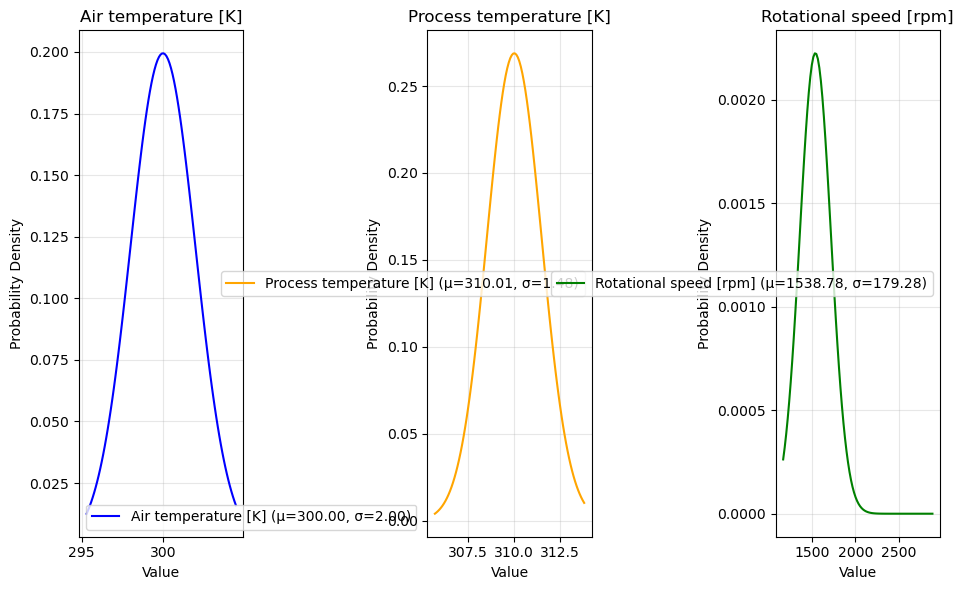

In [206]:
def plot_all_features():
    fig, ax = plt.subplots(1, 3, figsize=(10, 6))
    for sub_ax, ftr in zip(ax, ftr_objs.values()):                                                                                          
        ftr.plot(sub_ax)                                                                                                       
        sub_ax.set_title(ftr.feature_name)                                                                                       
        sub_ax.set_xlabel("Value")        
        sub_ax.set_ylabel("Probability Density")                                                                                 
        sub_ax.legend()                                                                                                          
        sub_ax.grid(True, alpha=0.3)
                                                                                                 
    plt.tight_layout()                                                                                                     
    plt.show()

plot_all_features()

### Method to plot the 3 graphs separately

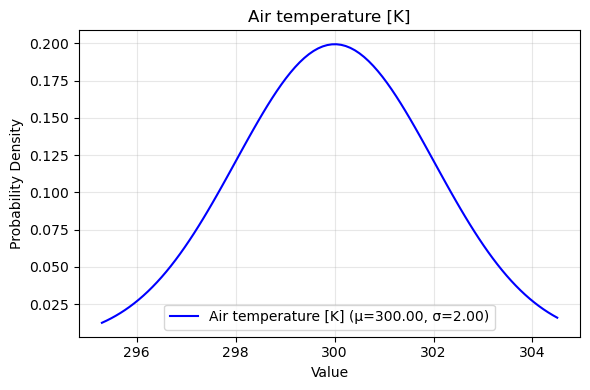

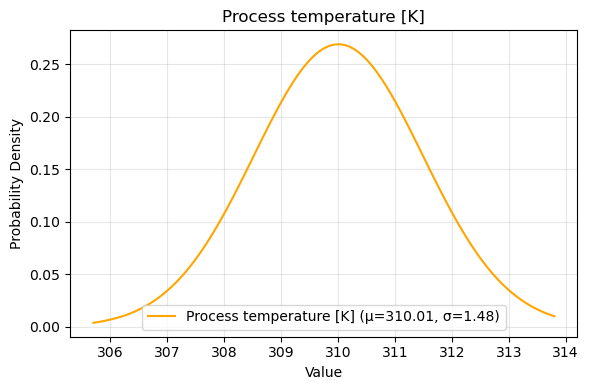

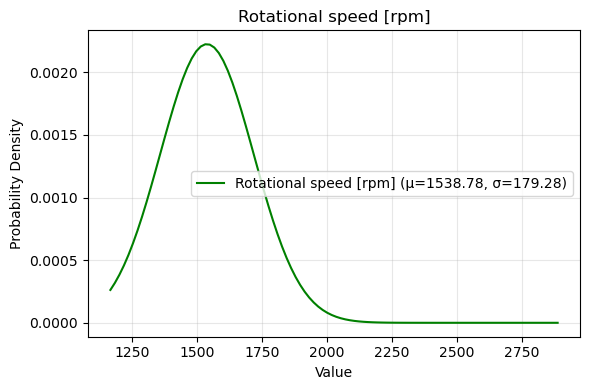

In [207]:
def plot_features_separate():
    for ftr in ftr_objs.values():
        fig, ax = plt.subplots(figsize=(6, 4))
        ftr.plot(ax)
        ax.set_title(ftr.feature_name)
        ax.set_xlabel("Value")
        ax.set_ylabel("Probability Density")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_features_separate()


In [208]:
for ftr_obj in ftr_objs.values():
    mle_mu, mle_sigma = ftr_obj.mle_estimate()
    print(f"MLE Estimates for {ftr_obj.feature_name}: μ = {mle_mu:.2f}, σ = {mle_sigma:.2f}")

# Test likelihood for different parameters
mu_test, sigma_test = 300, 2
ftr_obj = ftr_objs['Air temperature [K]']
likelihood_value = ftr_obj.compute_likelihood(mu_test, sigma_test)
log_likelihood_value = ftr_obj.compute_log_likelihood(mu_test, sigma_test)

print(f"L({mu_test}, {sigma_test}) = {likelihood_value:.6e}")
print(f"log L({mu_test}, {sigma_test}) = {log_likelihood_value:.6f}")

MLE Estimates for Air temperature [K]: μ = 300.00, σ = 2.00
MLE Estimates for Process temperature [K]: μ = 310.01, σ = 1.48
MLE Estimates for Rotational speed [rpm]: μ = 1538.78, σ = 179.28
L(300, 2) = 0.000000e+00
log L(300, 2) = -21121.680888


### Code trial - scratchpad

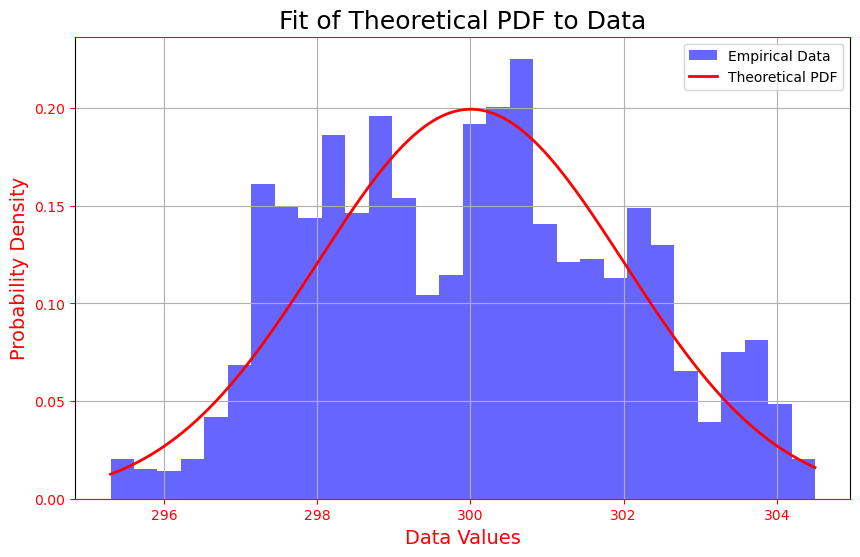

In [209]:
#Visualization of empirical histogram
plt.figure(figsize=(10, 6))
ax = plt.axes()
ax.set_xlabel('Air Temperature [K]', fontsize=18)
ax.set_ylabel('Density', fontsize=18)
ax.spines['bottom'].set_color('red')
ax.spines['top'].set_color('red')
ax.yaxis.label.set_color('red')
ax.xaxis.label.set_color('red')
ax.grid()
ax.tick_params(axis='x', colors='red')
ax.tick_params(axis='y', colors='red')

# Empirical histogram
plt.hist(air_temp, bins=30, density=True, alpha=0.6, color='blue', label='Empirical Data')

# Theoretical PDF
x = np.linspace(np.min(air_temp), np.max(air_temp), 1000)
pdf_theoretical = (1 / (np.sqrt(2 * np.pi) * air_temp_sigma)) * np.exp(-((x - air_temp_mu) ** 2) / (2 * air_temp_sigma ** 2))
plt.plot(x, pdf_theoretical, 'r', linewidth=2, label='Theoretical PDF')  # Theoretical distribution

plt.title('Fit of Theoretical PDF to Data', color='black', fontsize=18)
plt.xlabel('Data Values', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.legend()
plt.show()
